 # 🛒 Retail Store Sales Analysis (EDA Project)

## 📌 Objective
This project performs **Exploratory Data Analysis (EDA)** on retail store sales data to understand customer behavior, sales performance, and key business insights.

---

## 🎯 Goals
- Understand dataset structure and quality
- Clean and preprocess raw data
- Analyze sales trends and patterns
- Identify top-performing categories and products
- Evaluate payment methods and location performance
- Generate actionable business insights

---

## 🧠 What is EDA?
**Exploratory Data Analysis (EDA)** is the process of analyzing datasets to summarize their main characteristics using statistics and visualizations.

---

## ❓ Why EDA is Important?
- Helps understand the dataset
- Identifies missing or incorrect data
- Detects patterns and trends
- Supports better business decision-making
- Prepares data for machine learning

 ## 📦 Step 1: Import Required Libraries

In this step, we import essential Python libraries for:
- Data manipulation → Pandas, NumPy
- Data visualization → Matplotlib, Seaborn

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

## 📂 Step 2: Load Dataset

We load the dataset into a Pandas DataFrame and verify:
- Total number of records
- Successful data loading

In [50]:
df = pd.read_csv(r"D:\All\Python\Python Projects\EDA_Project\retail_store_sales.csv")
print("Data loaded successfully!")
print(f'Total Results : {len(df)}')

Data loaded successfully!
Total Results : 12575


## 👀 Step 3: Initial Data Exploration

We perform a quick overview of the dataset:
- First few rows (`head()`)
- Last few rows (`tail()`)
- Dataset shape (rows and columns)

This helps us understand the structure and content of the data.

In [52]:
# First Look Data And Cleaning Process

print("=" * 50)
print("First 5 rows of our data:")
print("=" * 50)
print(df.head())

print("\n" + "=" * 50)
print("Last 3 rows of our data:")
print("=" * 50)
print(df.tail(3))

print("\n" + "=" * 50)
print("Dataset Information:")
print("=" * 50)

print(f'Dataset Shape : {df.shape}')
print(f'Number of Rows (rows): {df.shape[0]}')
print(f"Number of columns: {df.shape[1]}")

First 5 rows of our data:
  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3     

In [53]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


## 🧹 Step 4: Data Cleaning & Preprocessing

Data cleaning ensures the dataset is accurate and ready for analysis.

### ✔️ Tasks Performed:
- Checked data types and structure
- Identified missing values
- Removed duplicate records
- Renamed columns for better readability
- Standardized text values (e.g., "cash", "Cash", " CASH" → "Cash")
- Fixed invalid numeric values (negative sales → handled)
- Replaced missing categorical values with "N/A"

---

### 💡 Why Data Cleaning is Important?
- Prevents incorrect analysis
- Ensures consistency
- Improves data quality

In [54]:
print("=" * 50)
print("Dataset Information:")
print("=" * 50)
df.info()


print("\n" + "=" * 50)
print("Data types of each column:")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("Missing values in each column:")
print("=" * 50)

missing_values = df.isnull().sum()
print(f"Total missing values {missing_values.sum()}")
print("=" * 50)

print("Duplicate Values :",df.duplicated().sum())
print("Shape Understand :",df.shape)
print("Columns :",df.columns)

# Rename Column
cleaned_col = df.columns = df.columns.str.replace(' ','_')
print("Rename Columns: ",cleaned_col)

multi_col_rename = df.rename(columns={'Item':'Product_Item','Location':'Location_Channel'}, inplace=True)
print("Rename Multiple Columns :",multi_col_rename)

# Remove Duplicates 
remove_duplicates = df.drop_duplicates(inplace=True)
print("Remove Duplicates :",remove_duplicates)


# Clean Text Columns 
text_cols = ["Category","Product_Item","Payment_Method","Location_Channel","Discount_Applied"]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
)
df[text_cols].head() # Top 5 Row with standardize text


# fix invalid retails sales rate
col_num_value = ["Price_Per_Unit","Quantity","Total_Spent"]

# Step 1: Replace negative values with NaN
for col in col_num_value:
    df.loc[df[col] < 0, col] = np.nan

# Step 2: Replace NaN (blank values) with 0
df[col_num_value] = df[col_num_value].fillna(0)
    
# Check result
df[col_num_value].head(5)

# Fix Item Value
fixed_text_blanks_value = [
    "Category","Product_Item","Payment_Method","Location_Channel"
]

df[fixed_text_blanks_value] = (
    df[fixed_text_blanks_value]
    .replace(["", "nan", "Nan", "None"], np.nan)   # catch ALL cases
    .fillna("N/A")
)

# Fix Discount Applied 
df["Discount_Applied"] = (
    df["Discount_Applied"]
    .replace(["Nan", "nan", ""], "False")
    .astype(str)
    .str.strip()
    .str.title()
)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB

Data types of each column:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent

## ⚙️ Step 5: Feature Engineering

Feature engineering involves creating new columns from existing data to improve analysis.

### ✔️ Features Created:
- **Profit_Tier** → Categorized sales into Low, Medium, High
- **Month & Year** → Extracted from transaction date

---

### 💡 Why Feature Engineering?
- Simplifies analysis
- Helps identify patterns
- Adds business value

In [55]:
df["Profit_Tier"] = pd.cut(
    df["Total_Spent"],
    bins=[-1,100,200, float('inf')],
    labels=['Low', 'Medium', 'High']
)

In [56]:
# Data Column -> Convert Date Type
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"], format="mixed", dayfirst=True)

# Extract Month and Year as separate columns
df["Month"] = df["Transaction_Date"].dt.month        # 1, 2, 3 ... 12
df["Year"]  = df["Transaction_Date"].dt.year         # 2023, 2024 ...

In [57]:
df

,Transaction_ID,Customer_ID,Category,Product_Item,Price_Per_Unit,Quantity,Total_Spent,Payment_Method,Location_Channel,Transaction_Date,Discount_Applied,Profit_Tier,Month,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_Pat,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,Medium,4,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_Milk,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,High,7,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_But,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,Low,10,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_Bev,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,High,5,2022
4,TXN_4575373,CUST_05,Food,Item_6_Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,Low,10,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_Pat,38.0,4.0,152.0,Credit Card,In-Store,2023-09-03,False,Medium,9,2023
12571,TXN_4009414,CUST_03,Beverages,Item_2_Bev,6.5,9.0,58.5,Cash,Online,2022-08-12,False,Low,8,2022
12572,TXN_5306010,CUST_11,Butchers,Item_7_But,14.0,10.0,140.0,Cash,Online,2024-08-24,False,Medium,8,2024
12573,TXN_5167298,CUST_04,Furniture,Item_7_Fur,14.0,6.0,84.0,Cash,Online,2023-12-30,True,Low,12,2023


## 📊 Step 6: Statistical Summary

We analyze numerical data using:
- Mean (average)
- Median
- Maximum & Minimum
- Standard Deviation
- Variance

---

### 💡 Purpose:
- Understand data distribution
- Detect outliers
- Measure variability

In [58]:
print("=" * 70)
print("Statistical Summary of Numerical Columns:")
print("=" * 70)
print(df.describe())

print("\n" + "=" * 70)
print("Detailed Statistics for Retail Average:")
print("=" * 70)

print(f"Mean Average : {df['Total_Spent'].mean():.2f}")
print(f"Median Average : {df['Total_Spent'].median():.2f}")
print(f"Highest Average Sales Score : {df['Total_Spent'].max():.2f}")
print(f"Lowest Average : {df['Total_Spent'].min():.2f}")
print(f"Standard Deviation: {df['Total_Spent'].std():.2f}")
print(f"Variance : {df['Total_Spent'].var():.2f}")


Statistical Summary of Numerical Columns:
       Price_Per_Unit      Quantity   Total_Spent  \
count    12575.000000  12575.000000  12575.000000   
mean        22.234314      5.270457    123.425129   
min          0.000000      0.000000      0.000000   
25%         12.500000      3.000000     43.500000   
50%         23.000000      5.000000    100.000000   
75%         32.000000      8.000000    184.000000   
max         41.000000     10.000000    410.000000   
std         11.618742      3.029325     96.514921   

                    Transaction_Date         Month          Year  
count                          12575  12575.000000  12575.000000  
mean   2023-07-12 20:23:41.105368064      6.366441   2023.042386  
min              2022-01-01 00:00:00      1.000000   2022.000000  
25%              2022-09-30 00:00:00      3.000000   2022.000000  
50%              2023-07-13 00:00:00      6.000000   2023.000000  
75%              2024-04-24 00:00:00      9.000000   2024.000000  
max        

# 🧠 Step 7: Business Analysis Sections

## 🏷 Category-wise Sales Analysis

We analyze:
- Number of sales per category
- Average sales by category

👉 Helps identify best-performing categories

In [59]:
print("=" * 50)
print("Number of Per Category Sales:")
print("=" * 50)

print(df['Category'].value_counts())

print("\n" + "=" * 50)
print( "Category Wise Average Sales Analysis:")
print("=" * 50)
print(df.groupby("Category")["Total_Spent"].mean().sort_values(ascending=False))


print("\n" + "=" * 50)
print("Top 3 Item Of Retails Sales:")
print("=" * 50)
print(df.nlargest(3,'Total_Spent')[['Category', 'Product_Item', 'Price_Per_Unit', 'Quantity', 'Total_Spent']])

Number of Per Category Sales:
Category
Electric Household Essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers And Electric Accessories    1558
Patisserie                            1528
Name: count, dtype: int64

Category Wise Average Sales Analysis:
Category
Butchers                              132.728316
Electric Household Essentials         128.104023
Beverages                             125.748245
Furniture                             122.759271
Food                                  122.677582
Computers And Electric Accessories    122.395700
Patisserie                            119.218259
Milk Products                         113.707071
Name: Total_Spent, dtype: float64

Top 3 Item Of Retails Sales:
      Category  Product_Item  Price_Per_Unit  Quantity  Total_Spent
27   Furniture   It

## 💳 Payment Method Analysis

We analyze:
- Most used payment methods
- Percentage distribution

👉 Helps understand customer preferences

In [60]:
print("=" * 50)
print("Payment Method Distribution Analysis")
print("=" * 50)
print(df['Payment_Method'].value_counts().sort_index())

print((df['Payment_Method'].value_counts(normalize=True) * 100).round(1))


print("\n" + "=" * 50)
print("Payment_Method with Product_Item")
print("=" * 50)

payment_method_item = df[df["Payment_Method"].str.strip().str.lower() == "cash"][["Total_Spent","Payment_Method","Location_Channel","Product_Item"]]
print(payment_method_item)
print(f'\nTotal Payment Methods By Items : {len(payment_method_item)}')

Payment Method Distribution Analysis
Payment_Method
Cash              4310
Credit Card       4121
Digital Wallet    4144
Name: count, dtype: int64
Payment_Method
Cash              34.3
Digital Wallet    33.0
Credit Card       32.8
Name: proportion, dtype: float64

Payment_Method with Product_Item
       Total_Spent Payment_Method Location_Channel Product_Item
9            109.5           Cash           Online  Item_22_But
10            72.0           Cash         In-Store   Item_3_But
12            45.5           Cash           Online  Item_2_Food
16           232.0           Cash           Online  Item_17_Pat
22            66.5           Cash         In-Store   Item_4_Ehe
...            ...            ...              ...          ...
12566         20.0           Cash           Online  Item_1_Milk
12571         58.5           Cash           Online   Item_2_Bev
12572        140.0           Cash           Online   Item_7_But
12573         84.0           Cash           Online   Item_7_Fu

# 💡 Step 8: Insights and Patterns

## 🏆 Top Performing Products

We identify top 3 products based on total sales.

👉 Helps business focus on high-revenue items

## 📍 Location Channel Analysis

We compare performance between:
- Online sales
- In-store sales

👉 Helps optimize sales strategy

## 📉 Low Performing Products

We identify products with low sales.

👉 Helps improve marketing or pricing strategy

In [61]:
print("=" * 50)
print("Product Item who might need extra help (Below 75%):")
print("=" * 50)
print(df[df['Total_Spent'] < 75][["Total_Spent","Payment_Method","Location_Channel","Product_Item"]])


print("\n" + "=" * 50)
print("Location_Channel Performance Analysis:")
print("=" * 50)
location_channerl_per = df.groupby('Location_Channel')['Total_Spent'].mean().sort_values(ascending=False)
print(f"Best performing Location_Channel: {location_channerl_per.index[0]}")
print(f"Average score: {location_channerl_per.iloc[0]:.2f}")


print("\n" + "=" * 50)
print("Location_Channel Performance (In-Store vs Online):")
print("=" * 50)
print(df.groupby('Location_Channel')['Total_Spent'].mean())

print("\n" + "=" * 50)
print("Profit_Tier Performance:")
print("=" * 50)
print(df.groupby('Profit_Tier')['Total_Spent'].mean())

Product Item who might need extra help (Below 75%):
       Total_Spent  Payment_Method Location_Channel Product_Item
2             43.0     Credit Card           Online  Item_12_But
6             40.0     Credit Card         In-Store  Item_1_Food
7              0.0  Digital Wallet         In-Store          N/A
8             27.5     Credit Card         In-Store  Item_16_Fur
10            72.0            Cash         In-Store   Item_3_But
...            ...             ...              ...          ...
12566         20.0            Cash           Online  Item_1_Milk
12567         40.0     Credit Card         In-Store   Item_3_But
12569         45.0  Digital Wallet         In-Store   Item_1_Pat
12571         58.5            Cash           Online   Item_2_Bev
12574         51.0            Cash           Online  Item_9_Food

[4922 rows x 4 columns]

Location_Channel Performance Analysis:
Best performing Location_Channel: Online
Average score: 124.55

Location_Channel Performance (In-Store 

# 📈 Step 9: Visualization Section (VERY IMPORTANT)

## Visualization helps in understanding patterns and trends more effectively.

We use:
- Heatmaps → correlation
- Line charts → trends
- Bar charts → comparisons
- Scatter plots → relationships

# Retail Sales Performance - EDA with Correlation Graphs

# This notebook includes various correlation visualizations to better understand relationships between Product,Category and total performance.

# 🔍 Correlation Analysis
# Let's visualize correlations among numeric variables using different types of plots.

# 1️⃣ 📊 Correlation Heatmap (Relationship Overview)

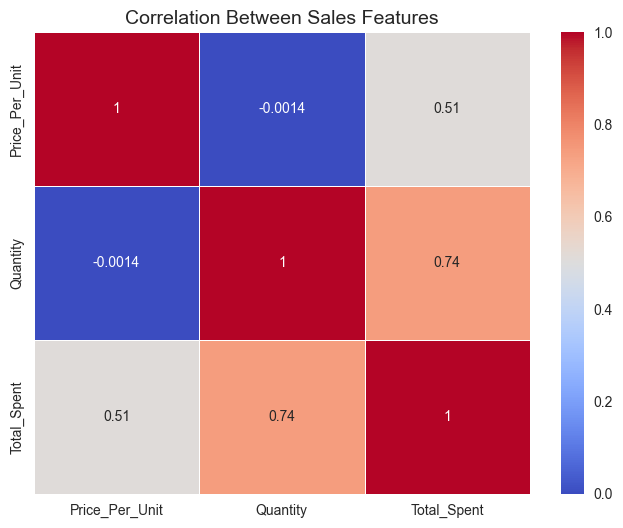

In [38]:
corr = df[["Price_Per_Unit","Quantity","Total_Spent"]].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Between Sales Features", fontsize=14)
plt.show()

### 🔍 Insight: Correlation Analysis

This heatmap shows relationships between numerical variables.

- Strong positive correlation → variables increase together
- Weak correlation → little or no relationship

👉 Key Focus:
- Quantity vs Total_Spent → Strong relationship expected
- Price_Per_Unit vs Total_Spent → Moderate impact

📌 Business Meaning:
Higher quantity purchased has a direct impact on total sales.

# 2️⃣ 📅 Monthly Sales Trend (MOST IMPORTANT GRAPH ⭐)

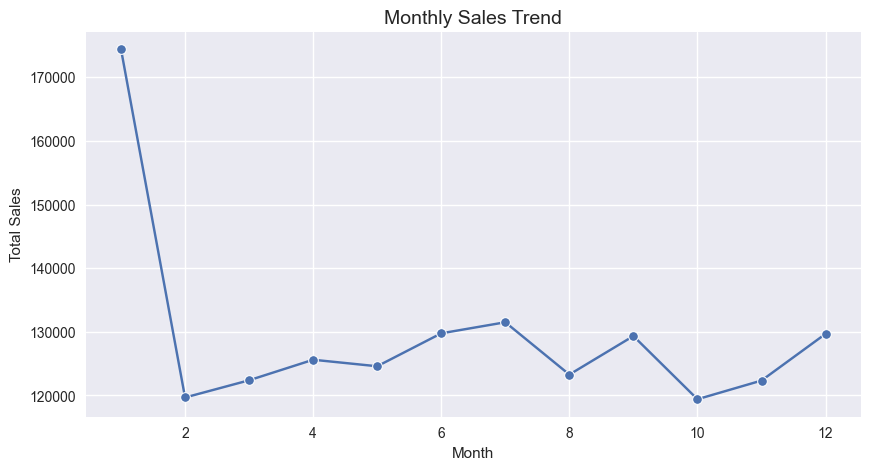

In [40]:
monthly_sales = df.groupby("Month")["Total_Spent"].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values,  marker='o')

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

### 📅 Insight: Monthly Sales Trend

This line chart shows how sales change over time.

👉 Why important?
- Identifies peak sales months
- Detects seasonal trends

📌 Business Meaning:
- High sales months → focus marketing
- Low sales months → improve strategy

# 3️⃣ 🏷 Category-wise Sales (Comparison Graph)

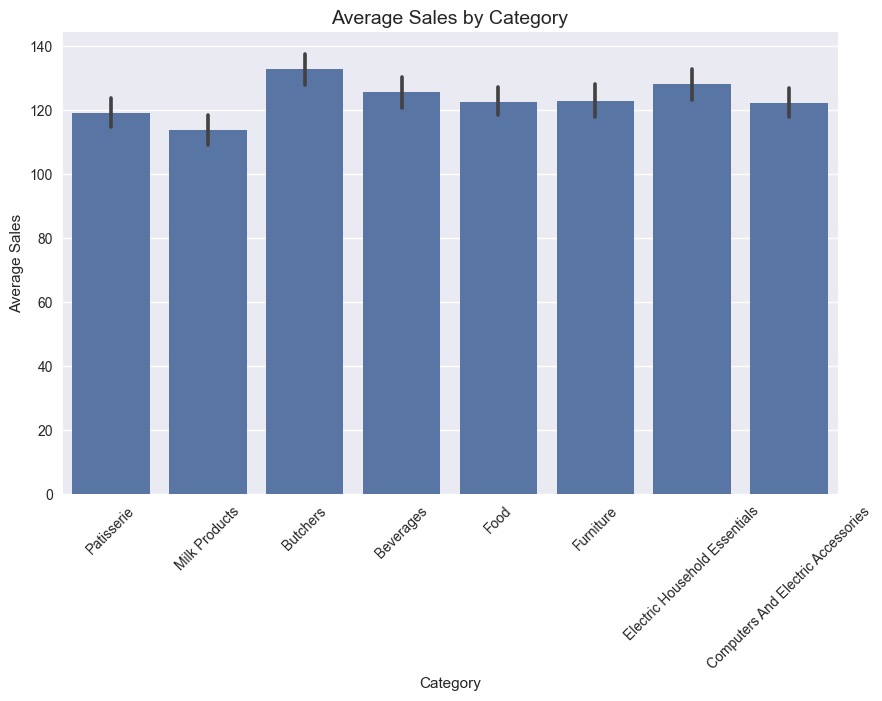

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="Category",
    y="Total_Spent",
    estimator=np.mean
)

plt.title("Average Sales by Category", fontsize=14)
plt.xticks(rotation=45)
plt.ylabel("Average Sales")

plt.show()

### 🏷 Insight: Category Performance

This bar chart compares average sales across categories.

👉 Helps identify:
- Best-performing categories
- Low-performing categories

📌 Business Meaning:
Focus on high-performing categories to maximize revenue.

# 4️⃣ 🔵 Scatter Plot (Relationship + Storytelling)

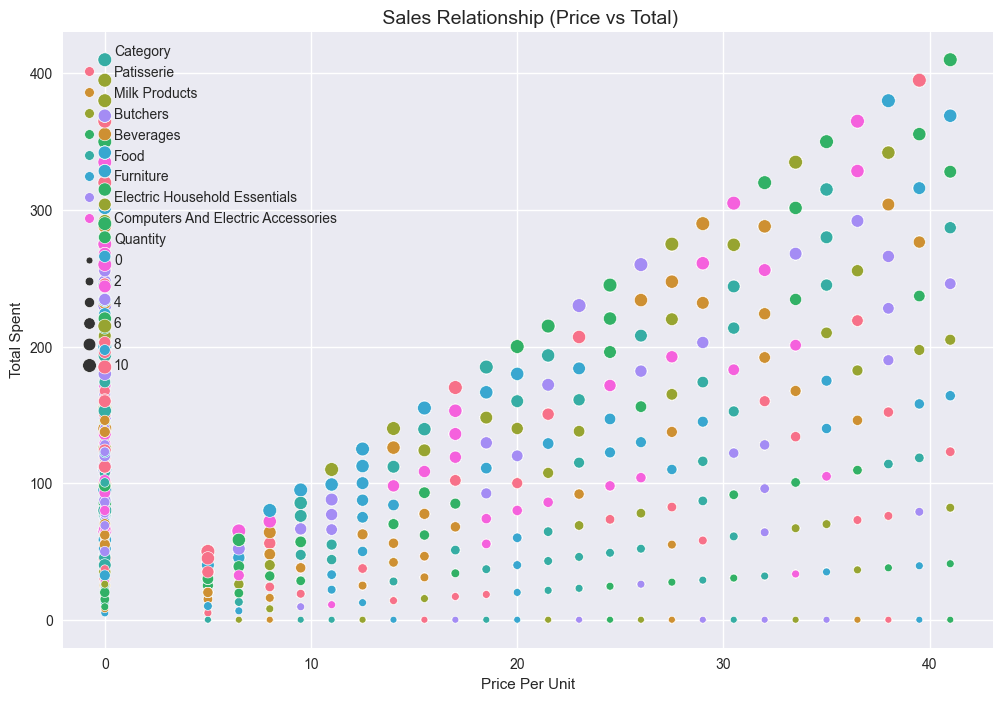

In [48]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="Price_Per_Unit",
    y="Total_Spent",
    hue="Category",
    size="Quantity"
)

plt.title(" Sales Relationship (Price vs Total)", fontsize=14)
plt.xlabel("Price Per Unit")
plt.ylabel("Total Spent")

plt.show()

In [18]:
# Export the Excel Data
df.to_excel("Retail_Cleaned_Sales_Data.xlsx" ,index=False)

## 💡 Key Insights

- Certain categories generate higher average sales
- Online vs In-store performance shows noticeable differences
- Specific payment methods are more popular among customers
- Some products consistently underperform
- Sales trends vary across months

---

## 📌 Conclusion

EDA helps transform raw data into meaningful insights that support better business decisions.

This analysis can help:
- Improve sales strategies
- Optimize product offerings
- Enhance customer experience